In [11]:
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.layers import Input,Conv2D,Conv2DTranspose,Flatten,Dense,MaxPooling2D
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

In [12]:
batchSize = 16
imageSize = 128
epochs = 200

In [13]:
import kagglehub
path = kagglehub.dataset_download("shravankumar9892/image-colorization")
print(path)

C:\Users\morga\.cache\kagglehub\datasets\shravankumar9892\image-colorization\versions\4


In [14]:
grayPath = f"{path}/l/gray_scale.npy"
for i in range(1):
    colPath = f"{path}/ab/ab/ab{i+1}.npy"
colImage = np.load(colPath)[:100]
grayImage = np.load(grayPath)[:100]

In [15]:
print(colImage.shape)
print(grayImage.shape)

(100, 224, 224, 2)
(100, 224, 224)


In [30]:
def preprocessing(grayImage,colImage):
    grayResize = np.array([cv2.resize(image,(imageSize,imageSize))for image in grayImage])
    colResize = np.array([cv2.resize(image,(imageSize,imageSize))for image in colImage])
    grayResize = grayResize[...,np.newaxis]
    colResize = colResize/255
    if colResize.shape[-1] == 1:
        print("colImage has 1 channel - expanding it to 3")
        colResize = np.repeat(colResize,3,axis=-1)

    elif colResize.shape[-1] == 2:
        print("colImage has 2 channels - expanding to 3")
        colResize = np.concatenate((colResize,colResize[...,:1]),axis=-1)

    elif colResize.shape[-1] != 3:
        print("unexpected colImage with more than 3 channels")
        raise ValueError(f"ERROR - unexpected image with {colResize.shape[-1]} channels")

    return grayResize, colResize

gImage, cImage = preprocessing(grayImage,colImage)

colImage has 2 channels - expanding to 3


In [31]:
print(np.array(gImage).shape)

(100, 128, 128, 1)


In [32]:
Xtrain,Xtest,ytrain,ytest = train_test_split(gImage,cImage,test_size=0.2,random_state=1)
trainDS = tf.data.Dataset.from_tensor_slices((Xtrain,ytrain)).batch(batchSize)
testDS  = tf.data.Dataset.from_tensor_slices((Xtest,ytest)).batch(batchSize)


In [33]:
print(np.array(Xtrain).shape)

(80, 128, 128, 1)


In [34]:
from tensorflow.keras.layers import LeakyReLU
def generate():
    inputs = Input(shape=(imageSize,imageSize,1))
    X = Conv2D(16,(5,5),padding="same")(inputs)
    X = LeakyReLU()(X)
    X = Conv2D(32,(3,3),padding="same")(X)
    X = LeakyReLU()(X)
    X = Conv2D(64,(3,3),padding="same")(X)
    X = LeakyReLU()(X)
    bottleneck = Conv2D(128,(3,3),activation="tanh",padding="same")(X)
    X = Conv2DTranspose(64,(3,3),padding="same")(bottleneck)
    X = LeakyReLU()(X)
    X = Conv2DTranspose(32,(3,3),padding="same")(X)
    X = LeakyReLU()(X)
    outputs = Conv2DTranspose(3,(3,3),activation="sigmoid",padding="same")(X)
    return Model(inputs,outputs)

In [35]:
def discriminate():
    discModel = Sequential([
        Conv2D(32,(7,7),strides=2,activation="relu",input_shape=(imageSize,imageSize,3)),
        MaxPooling2D(),
        Conv2D(64,(5,5),strides=2,activation="relu"),
        MaxPooling2D(),
        Flatten(),
        Dense(128,activation="relu"),
        Dense(1,activation="sigmoid")
    ] )
    return discModel

In [36]:
generator = generate()
discriminator = discriminate()
mse = MeanSquaredError()
bce = BinaryCrossentropy()
genOp = Adam(learning_rate=0.0005)
disOp = Adam(learning_rate=0.0005)

In [37]:
@tf.function
def trainStep(grayImage,colImage):
    with tf.GradientTape() as genTape, tf.GradientTape() as discTape:
        genImages = generator(grayImage,training=True)
        realOutput = discriminator(colImage,training=True)
        fakeOutput = discriminator(genImages,training=True)
        genLoss = mse(colImage,genImages)
        discLoss = bce(tf.ones_like(realOutput),realOutput) + bce(tf.zeros_like(fakeOutput),fakeOutput)
    genGrad = genTape.gradient(genLoss,generator.trainable_variables)
    discGrad = discTape.gradient(discLoss,discriminator.trainable_variables)
    genOp.apply_gradients(zip(genGrad,generator.trainable_variables))
    disOp.apply_gradients(zip(discGrad,discriminator.trainable_variables))
    return genLoss, discLoss

In [38]:
for i in range(1,epochs+1):
    print(f"Epoch {i} out of {epochs}")
    for grayBatch, colBatch in tqdm(trainDS):
        genLoss, disLoss = trainStep(grayBatch,colBatch)
    print("Generator loss = ",  genLoss.numpy())
    print("Discriminator loss = ", disLoss.numpy())

Epoch 1 out of 200


100%|██████████| 5/5 [00:07<00:00,  1.44s/it]


Generator loss =  0.07287646
Discriminator loss =  1.2983032
Epoch 2 out of 200


100%|██████████| 5/5 [00:06<00:00,  1.21s/it]


Generator loss =  0.013855201
Discriminator loss =  1.4291291
Epoch 3 out of 200


...

Generator loss =  0.005229632
Discriminator loss =  0.26979533
Epoch 199 out of 200


100%|██████████| 5/5 [00:05<00:00,  1.14s/it]


Generator loss =  0.005228995
Discriminator loss =  0.8572864
Epoch 200 out of 200


100%|██████████| 5/5 [00:05<00:00,  1.11s/it]

Generator loss =  0.0052288887
Discriminator loss =  0.37079382


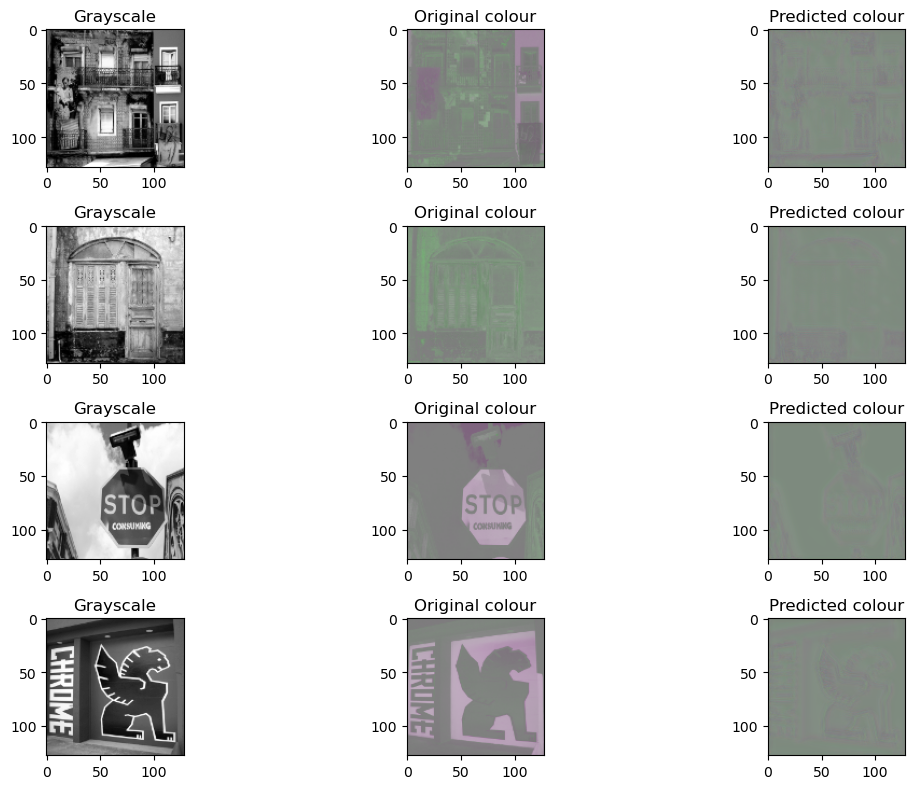

In [41]:
def display(generator,testData):
    for gray,colour in testData.take(1):
        predictions = generator(gray,training=False)
        fig,axes = plt.subplots(4,3,figsize=(12,8))
        for i in range(8,12):
            axes[i-8,0].imshow(gray[i].numpy().squeeze(),cmap="gray")
            axes[i-8,0].set_title("Grayscale")
            axes[i-8,1].imshow(colour[i].numpy())
            axes[i-8,1].set_title("Original colour")
            axes[i-8,2].imshow(predictions[i].numpy())
            axes[i-8,2].set_title("Predicted colour")
        plt.tight_layout()
        plt.show()

display(generator,testDS)